## Step 1 - Import Necessary Libraries

In [ ]:
#importing required libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Step 2 - Read Dataset

In [ ]:
#GitHub raw URLs
url_part1 = "https://raw.githubusercontent.com/RihalMahmood/CSSE445-Assignments/main/Datasets/PHFood_Brazil_Part1.csv"
url_part2 = "https://raw.githubusercontent.com/RihalMahmood/CSSE445-Assignments/main/Datasets/PHFood_Brazil_Part2.csv"

#Load the parts into DataFrames using the 'python' engine for parsing
df_part1 = pd.read_csv(url_part1, engine='python')
df_part2 = pd.read_csv(url_part2, engine='python')

#Combine the two parts into a single DataFrame
df = pd.concat([df_part1, df_part2], ignore_index=True)

In [ ]:
#show first 5 data sample
df.head()

,Unnamed: 0,Year,Food,Food (English),Region,State,Harvest Area (hectares),Food Production (tons),Energy (kcal),Protein (g),...,Authorized,Maximum Residue Limit (MRL),Acceptable Daily Intake (ADI),Residue Percentage,Food Acquisition (kg),Food Group (FG),Population Food Group,Bean Intake (Food Group),Vegetable Intake (Food Group),Fruit Intake (Food Group)
0,1,1974,ABACATE,AVOCADO,MIDWEST,DISTRITO FEDERAL,56.0,1176.0,1.411200e+09,2.622480e+07,...,NaN,NaN,NaN,NaN,NaN,FRUIT,NaN,NaN,NaN,NaN
1,2,1974,ABACAXI,PINEAPPLE,MIDWEST,DISTRITO FEDERAL,58.0,139.0,6.672000e+07,7.506000e+05,...,NaN,NaN,NaN,NaN,NaN,FRUIT,NaN,NaN,NaN,NaN
2,3,1974,ALHO,GARLIC,MIDWEST,DISTRITO FEDERAL,2.0,3.0,4.470000e+06,1.908000e+05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1974,AMENDOIM,PEANUT,MIDWEST,DISTRITO FEDERAL,25.0,21.0,1.190700e+08,5.418000e+06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1974,ARROZ,RICE,MIDWEST,DISTRITO FEDERAL,900.0,864.0,1.131370e+09,2.214333e+07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#show last 5 data sample
df.tail()

,Unnamed: 0,Year,Food,Food (English),Region,State,Harvest Area (hectares),Food Production (tons),Energy (kcal),Protein (g),...,Authorized,Maximum Residue Limit (MRL),Acceptable Daily Intake (ADI),Residue Percentage,Food Acquisition (kg),Food Group (FG),Population Food Group,Bean Intake (Food Group),Vegetable Intake (Food Group),Fruit Intake (Food Group)
439294,439295,2023,AVEIA,OAT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
439295,439296,2023,MILHO,CORN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
439296,439297,2023,SOJA,SOYBEAN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
439297,439298,2023,TRIGO,WHEAT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
439298,439299,2023,CANA,SUGARCANE,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 3 - Sanity Check

In [ ]:
#shape
df.shape

(439299, 52)

In [ ]:
#info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439299 entries, 0 to 439298
Data columns (total 52 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Unnamed: 0                     439299 non-null  int64  
 1   Year                           439299 non-null  int64  
 2   Food                           437103 non-null  object 
 3   Food (English)                 437103 non-null  object 
 4   Region                         438273 non-null  object 
 5   State                          438273 non-null  object 
 6   Harvest Area (hectares)        432688 non-null  float64
 7   Food Production (tons)         432688 non-null  float64
 8   Energy (kcal)                  432688 non-null  float64
 9   Protein (g)                    415804 non-null  float64
 10  Lipids (g)                     432688 non-null  float64
 11  Carbohydrates (g)              432688 non-null  float64
 12  Fiber (g)                     

In [ ]:
#finding missing values
df.isnull().sum()

,0
Unnamed: 0,0
Year,0
Food,2196
Food (English),2196
Region,1026
State,1026
Harvest Area (hectares),6611
Food Production (tons),6611
Energy (kcal),6611
Protein (g),23495


In [ ]:
#percentage of missing values in each column
missing_percentage = df.isna().mean() * 100

#Display the result
print("Percentage of missing values in each column:")
print(missing_percentage)

Percentage of missing values in each column:
Unnamed: 0                        0.000000
Year                              0.000000
Food                              0.499887
Food (English)                    0.499887
Region                            0.233554
State                             0.233554
Harvest Area (hectares)           1.504898
Food Production (tons)            1.504898
Energy (kcal)                     1.504898
Protein (g)                       5.348294
Lipids (g)                        1.504898
Carbohydrates (g)                 1.504898
Fiber (g)                         5.348294
Calcium (mg)                      1.504898
Magnesium (mg)                    1.848627
Manganese (mg)                    5.692023
Phosphorus (mg)                   5.348294
Iron (mg)                         5.348294
Potassium (mg)                    1.848627
Copper (mg)                       1.848627
Zinc (mg)                         1.848627
Selenium (mcg)                   14.633314
Retinol (

<Axes: >

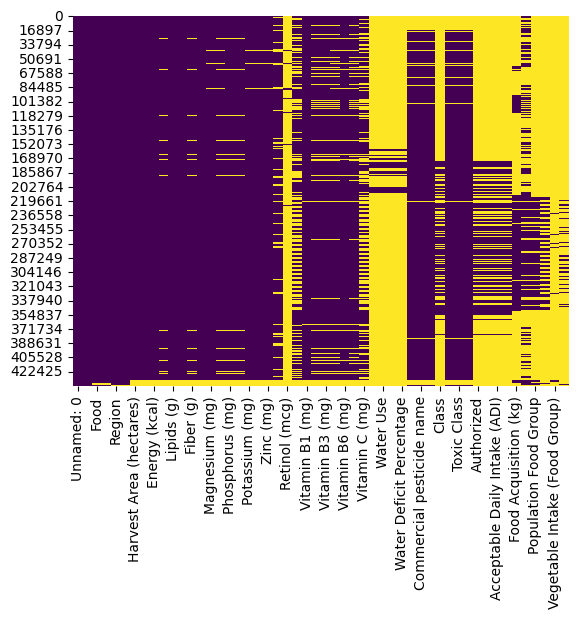

In [ ]:
#missing data heatmap
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

## Step 4 - Dropping Unnecessary Rows

In [ ]:
#Drop rows where target (Food Production) is missing
df = df.dropna(subset=['Food Production (tons)'])

## Step 5 - Drop Columns with Excessive Missing Data

In [ ]:
#Define columns with excessive missing data
columns_with_excessive_missing_data = [
    'Water Need', 'Water Use', 'Water Deficit', 'Water Deficit Percentage',
    'Retinol (mcg)', 'Selenium (mcg)'
]

#Drop columns with excessive missing data
df = df.drop(columns=columns_with_excessive_missing_data)
print(f"Dropped {len(columns_with_excessive_missing_data)} columns with excessive missing data.")
print(f"New shape: {df.shape}")

Dropped 6 columns with excessive missing data.
New shape: (432688, 46)


## Step 6 - Drop Irrelevant Columns

In [ ]:
#Define irrelevant columns not contributing to food production prediction
irrelevant_columns = [
    'Unnamed: 0', 'Food', 'CODE', 'Commercial pesticide name',
    'Pesticide', 'Class', 'Organic', 'Toxic Class', 'Environmental Impact',
    'Authorized', 'Maximum Residue Limit (MRL)', 'Acceptable Daily Intake (ADI)',
    'Residue Percentage', 'Vitamin A (mcg)', 'Vitamin B1 (mg)', 'Vitamin B2 (mg)',
    'Vitamin B3 (mg)', 'Equivalent Vitamin B3 (mg)', 'Vitamin B6 (mg)',
    'Folate (mcg)', 'Vitamin C (mg)', 'Fruit Intake (Food Group)', 'Vegetable Intake (Food Group)',
    'Bean Intake (Food Group)', 'Population Food Group', 'Food Group (FG)', 'Food Acquisition (kg)'
]

#Check which irrelevant columns actually exist in the dataset
existing_irrelevant_columns = [col for col in irrelevant_columns if col in df.columns]

#Drop existing irrelevant columns
df = df.drop(columns=existing_irrelevant_columns)
print(f"Dropped {len(existing_irrelevant_columns)} irrelevant columns out of {len(irrelevant_columns)} specified.")
print(f"New shape: {df.shape}")

Dropped 27 irrelevant columns out of 27 specified.
New shape: (432688, 19)


In [ ]:
#Display the updated dataframe after dropping columns
df.head()

,Year,Food (English),Region,State,Harvest Area (hectares),Food Production (tons),Energy (kcal),Protein (g),Lipids (g),Carbohydrates (g),Fiber (g),Calcium (mg),Magnesium (mg),Manganese (mg),Phosphorus (mg),Iron (mg),Potassium (mg),Copper (mg),Zinc (mg)
0,1974,AVOCADO,MIDWEST,DISTRITO FEDERAL,56.0,1176.0,1.411200e+09,2.622480e+07,118305600.0,9.196320e+07,6.585600e+07,1.176000e+08,2.822400e+08,1176000.000,4.704000e+08,1999200.000,4.127760e+09,3645600.000,4704000.000
1,1974,PINEAPPLE,MIDWEST,DISTRITO FEDERAL,58.0,139.0,6.672000e+07,7.506000e+05,166800.0,1.755570e+07,1.946000e+06,1.807000e+07,1.668000e+07,1640200.000,1.112000e+07,389200.000,1.598500e+08,139000.000,139000.000
2,1974,GARLIC,MIDWEST,DISTRITO FEDERAL,2.0,3.0,4.470000e+06,1.908000e+05,15000.0,9.918000e+05,6.300000e+04,5.430000e+06,7.500000e+05,50100.000,4.590000e+06,51000.000,1.203000e+07,9000.000,34800.000
3,1974,PEANUT,MIDWEST,DISTRITO FEDERAL,25.0,21.0,1.190700e+08,5.418000e+06,10340400.0,3.387300e+06,1.785000e+06,1.932000e+07,3.528000e+07,406140.000,7.896000e+07,961800.000,1.480500e+08,240240.000,686700.000
4,1974,RICE,MIDWEST,DISTRITO FEDERAL,900.0,864.0,1.131370e+09,2.214333e+07,16984483.2,2.208109e+08,2.352145e+07,4.452193e+07,5.022149e+08,5367042.432,9.056071e+08,2245729.536,6.429472e+08,173958.336,5841283.968


In [ ]:
#Get updated list of remaining columns
print(f"Number of remaining columns: {df.shape[1]}")
print("\nRemaining columns:")
print(df.columns.tolist())

Number of remaining columns: 19

Remaining columns:
['Year', 'Food (English)', 'Region', 'State', 'Harvest Area (hectares)', 'Food Production (tons)', 'Energy (kcal)', 'Protein (g)', 'Lipids (g)', 'Carbohydrates (g)', 'Fiber (g)', 'Calcium (mg)', 'Magnesium (mg)', 'Manganese (mg)', 'Phosphorus (mg)', 'Iron (mg)', 'Potassium (mg)', 'Copper (mg)', 'Zinc (mg)']


## Step 7 - Check Missing Values and Percentage After Dropping the columns

In [ ]:
#Check missing values after dropping columns
missing_count = df.isnull().sum()
missing_percent = df.isnull().mean() * 100

#Combine count and percentage into a DataFrame for better visualization
missing_data = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage': missing_percent.round(2)
})

#Sort by missing percentage descending
missing_data = missing_data.sort_values('Missing Percentage', ascending=False)

#Display only columns with missing values
print("Columns with missing values after cleaning:")
missing_data[missing_data['Missing Count'] > 0]

Columns with missing values after cleaning:


,Missing Count,Missing Percentage
Manganese (mg),18394,4.25
Fiber (g),16884,3.90
Phosphorus (mg),16884,3.90
Iron (mg),16884,3.90
Protein (g),16884,3.90
Potassium (mg),1510,0.35
Magnesium (mg),1510,0.35
Zinc (mg),1510,0.35
Copper (mg),1510,0.35


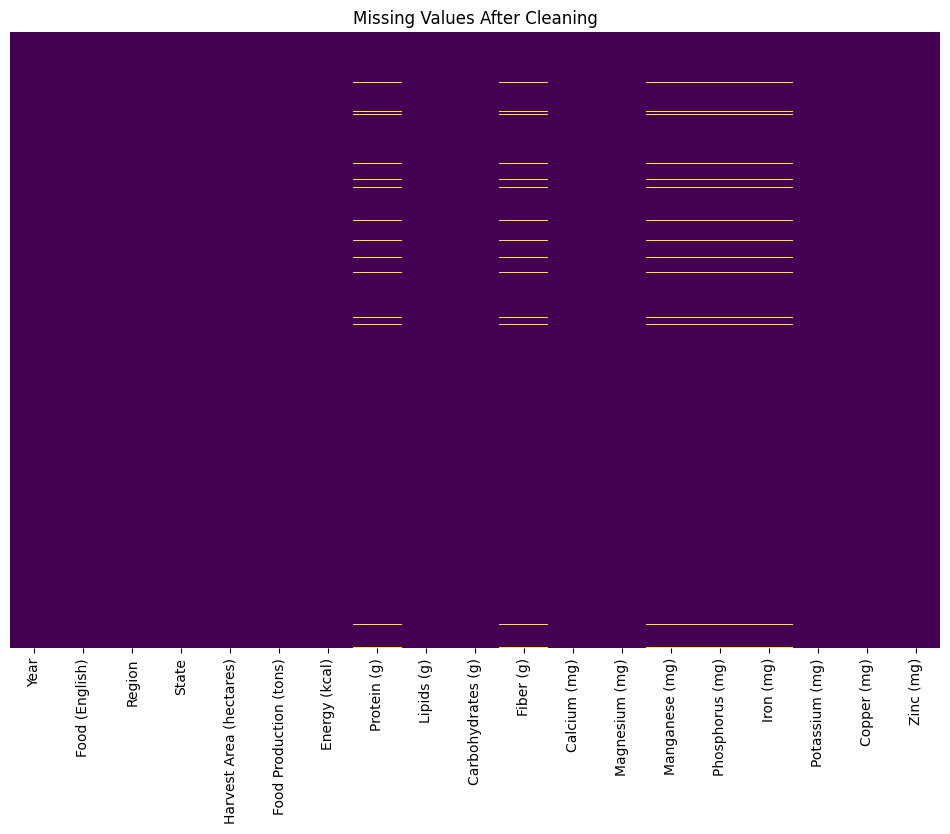

In [ ]:
#Visualize missing values after cleaning
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values After Cleaning')
plt.show()

In [ ]:
#Get summary statistics of the cleaned dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,432688.0,2.012484e+03,9.843981e+00,1974.0,2008.0,2.018000e+03,2.018000e+03,2.022000e+03
Harvest Area (hectares),432688.0,1.918558e+05,7.302814e+05,0.0,22.0,3.209000e+03,6.759900e+04,1.092462e+07
Food Production (tons),432688.0,1.546598e+06,1.518562e+07,0.0,136.0,1.690900e+04,1.681850e+05,4.504246e+08
Energy (kcal),432688.0,1.728772e+12,1.200997e+13,0.0,42120000.0,1.320042e+10,1.354287e+11,3.314224e+14
Protein (g),415804.0,5.799736e+10,3.437694e+11,0.0,616100.0,3.091297e+08,3.620611e+09,6.327424e+12
Lipids (g),432688.0,5.250432e+10,2.668720e+11,0.0,236600.0,1.194831e+08,2.218206e+09,4.415128e+12
Carbohydrates (g),432688.0,2.995857e+11,3.028176e+12,0.0,9908100.0,2.432425e+09,2.642131e+10,8.994979e+13
Fiber (g),415804.0,3.476083e+10,1.581537e+11,0.0,1151500.0,4.071340e+08,4.044447e+09,2.281523e+12
Calcium (mg),432688.0,3.477856e+11,2.204100e+12,0.0,16200000.0,2.541489e+09,2.926566e+10,3.878589e+13
Magnesium (mg),431178.0,3.817566e+11,1.978421e+12,0.0,20500000.0,4.212443e+09,4.239585e+10,3.270183e+13


In [ ]:
df.isnull().sum()

,0
Year,0
Food (English),0
Region,0
State,0
Harvest Area (hectares),0
Food Production (tons),0
Energy (kcal),0
Protein (g),16884
Lipids (g),0
Carbohydrates (g),0


## Step 8 - Converting String type scientific values to Numerical values

In [ ]:
def fix_scientific_notation(df):
    sci_pattern = r'^-?\d*\.?\d+e[+-]?\d+$'  # Regex to detect scientific notation
    fixed_df = df.copy()

    for col in fixed_df.columns:
        # Convert only if scientific notation is detected
        if fixed_df[col].astype(str).str.contains(sci_pattern, regex=True).any():
            try:
                # Convert entire column to numeric (handle mixed types, set errors to NaN)
                fixed_df[col] = pd.to_numeric(fixed_df[col], errors='coerce')
            except Exception as e:
                print(f"Warning: Could not convert column '{col}' - {str(e)}")
                continue

        # Make sure all numeric columns are float64
        if pd.api.types.is_numeric_dtype(fixed_df[col]):
            fixed_df[col] = fixed_df[col].astype('float64')

    return fixed_df

df_converted = fix_scientific_notation(df)

## Step 9 - Log Transform and Removing Outliers using IQR

In [ ]:
#Define columns
nutritional_cols = ['Energy (kcal)', 'Protein (g)', 'Lipids (g)', 'Carbohydrates (g)',
                    'Fiber (g)', 'Calcium (mg)', 'Magnesium (mg)', 'Manganese (mg)',
                    'Phosphorus (mg)', 'Iron (mg)', 'Potassium (mg)', 'Copper (mg)', 'Zinc (mg)']
numerical_cols = ['Harvest Area (hectares)'] + nutritional_cols
categorical_cols = ['Food (English)', 'Region', 'State']
other_cols = ['Year', 'Food Production (tons)']

#Higher thresholds assuming aggregates
max_thresholds = {
    'Harvest Area (hectares)': 1e7,      # 10M hectares
    'Food Production (tons)': 5e8,       # 500M tons
    'Energy (kcal)': 1e14,               # 100T kcal (total for region)
    'Protein (g)': 1e12,                 # 1T g
    'Lipids (g)': 1e12,                  # 1T g
    'Carbohydrates (g)': 1e13,           # 10T g
    'Fiber (g)': 1e12,                   # 1T g
    'Calcium (mg)': 1e13,                # 10T mg
    'Magnesium (mg)': 1e13,              # 10T mg
    'Manganese (mg)': 1e11,              # 100B mg
    'Phosphorus (mg)': 1e13,             # 10T mg
    'Iron (mg)': 1e12,                   # 1T mg
    'Potassium (mg)': 1e14,              # 100T mg
    'Copper (mg)': 1e11,                 # 100B mg
    'Zinc (mg)': 1e11                    # 100B mg
}

#Check and cap
for col in numerical_cols:
    extreme_count = (df_converted[col] > max_thresholds[col]).sum()
    print(f"{col}: {extreme_count} values > {max_thresholds[col]}")
    df_converted.loc[df_converted[col] > max_thresholds[col], col] = np.nan

#Check for negative values
neg_counts = (df_converted[numerical_cols] < 0).sum()
print("Negative value counts:\n", neg_counts)

Harvest Area (hectares): 226 values > 10000000.0
Energy (kcal): 587 values > 100000000000000.0
Protein (g): 5996 values > 1000000000000.0
Lipids (g): 6072 values > 1000000000000.0
Carbohydrates (g): 1536 values > 10000000000000.0
Fiber (g): 3570 values > 1000000000000.0
Calcium (mg): 4368 values > 10000000000000.0
Magnesium (mg): 4000 values > 10000000000000.0
Manganese (mg): 4063 values > 100000000000.0
Phosphorus (mg): 10167 values > 10000000000000.0
Iron (mg): 1045 values > 1000000000000.0
Potassium (mg): 1060 values > 100000000000000.0
Copper (mg): 750 values > 100000000000.0
Zinc (mg): 7280 values > 100000000000.0
Negative value counts:
 Harvest Area (hectares)    0
Energy (kcal)              0
Protein (g)                0
Lipids (g)                 0
Carbohydrates (g)          0
Fiber (g)                  0
Calcium (mg)               0
Magnesium (mg)             0
Manganese (mg)             0
Phosphorus (mg)            0
Iron (mg)                  0
Potassium (mg)             0
C

In [ ]:
#Log transform using dictionary-style approach
log_cols = {}
for col in numerical_cols:
    log_cols[col] = np.log1p(df_converted[col])  # log1p = log(1 + x)
log_df = pd.DataFrame(log_cols)

In [ ]:
#Detect and remove outliers in log-space
def detect_outlier_mask(col_series):
    Q1 = col_series.quantile(0.25)
    Q3 = col_series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (col_series < lower) | (col_series > upper)

outlier_mask_total = pd.DataFrame(False, index=df_converted.index, columns=numerical_cols)

for col in numerical_cols:
    mask = detect_outlier_mask(log_df[col])
    outlier_count = mask.sum()
    outlier_mask_total[col] = mask
    print(f"{col}: {outlier_count} outliers removed")
    df_converted.loc[mask, col] = np.nan

Harvest Area (hectares): 0 outliers removed
Energy (kcal): 96769 outliers removed
Protein (g): 0 outliers removed
Lipids (g): 0 outliers removed
Carbohydrates (g): 96769 outliers removed
Fiber (g): 96114 outliers removed
Calcium (mg): 96769 outliers removed
Magnesium (mg): 95376 outliers removed
Manganese (mg): 0 outliers removed
Phosphorus (mg): 96114 outliers removed
Iron (mg): 0 outliers removed
Potassium (mg): 95376 outliers removed
Copper (mg): 0 outliers removed
Zinc (mg): 0 outliers removed


## Step 10 - Imputing Missing values

In [ ]:
#Drop duplicates
df_converted = df_converted.drop_duplicates()

In [ ]:
#Impute missing values

#Impute numerical with median
for col in numerical_cols:
    df_converted[col] = df_converted[col].fillna(df_converted[col].median())

#Impute categorical with mode
for col in categorical_cols:
    df_converted[col] = df_converted[col].fillna(df_converted[col].mode()[0])

#Impute other columns with median (or adapt if needed)
for col in other_cols:
    df_converted[col] = df_converted[col].fillna(df_converted[col].median())

<ipython-input-24-bcf430ab32f8>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_converted[col] = df_converted[col].fillna(df_converted[col].median())
<ipython-input-24-bcf430ab32f8>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_converted[col] = df_converted[col].fillna(df_converted[col].mode()[0])
<ipython-input-24-bcf430ab32f8>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in

In [ ]:
#Check for any remaining NaN values
print("\nNaNs remaining:")
print(df_converted.isnull().sum())
print("\nShape of final dataset:", df_converted.shape)


NaNs remaining:
Year                       0
Food (English)             0
Region                     0
State                      0
Harvest Area (hectares)    0
Food Production (tons)     0
Energy (kcal)              0
Protein (g)                0
Lipids (g)                 0
Carbohydrates (g)          0
Fiber (g)                  0
Calcium (mg)               0
Magnesium (mg)             0
Manganese (mg)             0
Phosphorus (mg)            0
Iron (mg)                  0
Potassium (mg)             0
Copper (mg)                0
Zinc (mg)                  0
dtype: int64

Shape of final dataset: (52727, 19)


## Step 11 - Creating target column for Classification

In [ ]:
#Creating target variable column if not already present
df_converted["Healthy"] = df_converted["Energy (kcal)"] < 250  # Initial rule-based labeling
df_converted["Healthy"] = df_converted["Healthy"].astype(int)

#Define a more comprehensive Health Score

df_converted["Health_Score"] = (
    df_converted["Protein (g)"] * 2 +               # More protein = better
    df_converted["Fiber (g)"] * 1.5 +               # Fiber is good
    df_converted["Calcium (mg)"] * 0.5 +            # Calcium is important
    df_converted["Iron (mg)"] * 0.5 +               # Iron contributes positively
    df_converted["Magnesium (mg)"] * 0.5 +          # Magnesium is good for health
    df_converted["Phosphorus (mg)"] * 0.5 +         # Phosphorus is essential
    df_converted["Potassium (mg)"] * 0.5 -          # Potassium is good
    df_converted["Carbohydrates (g)"] * 0.5 -       # Carbohydrates reduce the score
    df_converted["Lipids (g)"] * 1                  # Lipids (fats) reduce the score
)

#Classify as Healthy if above median Health Score
df_converted["Healthy"] = (df_converted["Health_Score"] >= df_converted["Health_Score"].median()).astype(int)

#Optionally, check the first few rows to ensure the changes
df_converted.head()

<ipython-input-26-28e1490b0250>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_converted["Healthy"] = df_converted["Energy (kcal)"] < 250  # Initial rule-based labeling
<ipython-input-26-28e1490b0250>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_converted["Healthy"] = df_converted["Healthy"].astype(int)
<ipython-input-26-28e1490b0250>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cav

,Year,Food (English),Region,State,Harvest Area (hectares),Food Production (tons),Energy (kcal),Protein (g),Lipids (g),Carbohydrates (g),...,Calcium (mg),Magnesium (mg),Manganese (mg),Phosphorus (mg),Iron (mg),Potassium (mg),Copper (mg),Zinc (mg),Healthy,Health_Score
0,1974.0,AVOCADO,MIDWEST,DISTRITO FEDERAL,56.0,1176.0,1.411200e+09,2.622480e+07,118305600.0,9.196320e+07,...,1.176000e+08,2.822400e+08,1176000.000,4.704000e+08,1999200.000,4.127760e+09,3645600.000,4704000.000,0,2.486946e+09
1,1974.0,PINEAPPLE,MIDWEST,DISTRITO FEDERAL,58.0,139.0,6.672000e+07,7.506000e+05,166800.0,1.755570e+07,...,1.807000e+07,1.668000e+07,1640200.000,1.112000e+07,389200.000,1.598500e+08,139000.000,139000.000,0,9.853015e+07
2,1974.0,GARLIC,MIDWEST,DISTRITO FEDERAL,2.0,3.0,4.470000e+06,1.908000e+05,15000.0,9.918000e+05,...,5.430000e+06,7.500000e+05,50100.000,4.590000e+06,51000.000,1.203000e+07,9000.000,34800.000,0,1.139070e+07
3,1974.0,PEANUT,MIDWEST,DISTRITO FEDERAL,25.0,21.0,1.190700e+08,5.418000e+06,10340400.0,3.387300e+06,...,1.932000e+07,3.528000e+07,406140.000,7.896000e+07,961800.000,1.480500e+08,240240.000,686700.000,0,1.427654e+08
4,1974.0,RICE,MIDWEST,DISTRITO FEDERAL,900.0,864.0,1.131370e+09,2.214333e+07,16984483.2,2.208109e+08,...,4.452193e+07,5.022149e+08,5367042.432,9.056071e+08,2245729.536,6.429472e+08,173958.336,5841283.968,0,1.000947e+09


In [ ]:
#Count the occurrences of each value in the 'Healthy' column
healthy_counts = df_converted["Healthy"].value_counts()

#Display the counts of Healthy = 1 and Healthy = 0
print(healthy_counts)

Healthy
1    36467
0    16260
Name: count, dtype: int64


In [ ]:
df_converted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52727 entries, 0 to 432660
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     52727 non-null  float64
 1   Food (English)           52727 non-null  object 
 2   Region                   52727 non-null  object 
 3   State                    52727 non-null  object 
 4   Harvest Area (hectares)  52727 non-null  float64
 5   Food Production (tons)   52727 non-null  float64
 6   Energy (kcal)            52727 non-null  float64
 7   Protein (g)              52727 non-null  float64
 8   Lipids (g)               52727 non-null  float64
 9   Carbohydrates (g)        52727 non-null  float64
 10  Fiber (g)                52727 non-null  float64
 11  Calcium (mg)             52727 non-null  float64
 12  Magnesium (mg)           52727 non-null  float64
 13  Manganese (mg)           52727 non-null  float64
 14  Phosphorus (mg)          5

## Step 12 - Encoding Categorical Data

In [ ]:
#Initialize the OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop='first')

#Fit and transform the categorical columns
encoded_array = encoder.fit_transform(df_converted[categorical_cols])

#Create a DataFrame with encoded columns
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(categorical_cols))

#Print shape checks
print("Shape of dataset_cleaned:", df_converted.shape)
print("Shape of encoded_df:", encoded_df.shape)
print("NaNs in encoded_df:", encoded_df.isnull().sum().sum())

#Combine the numerical columns with the encoded columns
data_encoded = pd.concat([
    df_converted.drop(categorical_cols, axis=1).reset_index(drop=True),
    encoded_df.reset_index(drop=True)
], axis=1)

#Print final checks
print("Shape of data_encoded:", data_encoded.shape)
print("NaNs in data_encoded:", data_encoded.isnull().sum().sum())
print("Healthy column distribution:", data_encoded['Healthy'].value_counts())

Shape of dataset_cleaned: (52727, 21)
Shape of encoded_df: (52727, 67)
NaNs in encoded_df: 0
Shape of data_encoded: (52727, 85)
NaNs in data_encoded: 0
Healthy column distribution: Healthy
1    36467
0    16260
Name: count, dtype: int64


In [ ]:
print("Missing values in data_encoded:\n", data_encoded.isnull().sum())

Missing values in data_encoded:
 Year                       0
Harvest Area (hectares)    0
Food Production (tons)     0
Energy (kcal)              0
Protein (g)                0
                          ..
State_RORAIMA              0
State_SANTA CATARINA       0
State_SAO PAULO            0
State_SERGIPE              0
State_TOCANTINS            0
Length: 85, dtype: int64


## Step 13 - Spliting The Data

In [ ]:
#Define features and targets
#Dropping 'Food Production (tons)', 'Healthy', and 'Health_Score'

columns_to_drop = ['Food Production (tons)', 'Healthy', 'Health_Score']

X_reg = data_encoded.drop(columns_to_drop, axis=1)
y_reg = data_encoded['Food Production (tons)']
X_clf = data_encoded.drop(columns_to_drop, axis=1)
y_clf = data_encoded['Healthy']

#Three-way split for regression
X_train_reg, X_temp_reg, y_train_reg, y_temp_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)
X_val_reg, X_test_reg, y_val_reg, y_test_reg = train_test_split(
    X_temp_reg, y_temp_reg, test_size=0.5, random_state=42
)

#Three-way split for classification
X_train_clf, X_temp_clf, y_train_clf, y_temp_clf = train_test_split(
    X_clf, y_clf, test_size=0.3, random_state=42
)
X_val_clf, X_test_clf, y_val_clf, y_test_clf = train_test_split(
    X_temp_clf, y_temp_clf, test_size=0.5, random_state=42
)

#Verify shapes
print("\nRegression split shapes:")
print("X_train_reg:", X_train_reg.shape)
print("X_val_reg:", X_val_reg.shape)
print("X_test_reg:", X_test_reg.shape)
print("y_train_reg:", y_train_reg.shape)
print("y_val_reg:", y_val_reg.shape)
print("y_test_reg:", y_test_reg.shape)

print("\nClassification split shapes:")
print("X_train_clf:", X_train_clf.shape)
print("X_val_clf:", X_val_clf.shape)
print("X_test_clf:", X_test_clf.shape)
print("y_train_clf:", y_train_clf.shape)
print("y_val_clf:", y_val_clf.shape)
print("y_test_clf:", y_test_clf.shape)


Regression split shapes:
X_train_reg: (36908, 82)
X_val_reg: (7909, 82)
X_test_reg: (7910, 82)
y_train_reg: (36908,)
y_val_reg: (7909,)
y_test_reg: (7910,)

Classification split shapes:
X_train_clf: (36908, 82)
X_val_clf: (7909, 82)
X_test_clf: (7910, 82)
y_train_clf: (36908,)
y_val_clf: (7909,)
y_test_clf: (7910,)


## Step 14 - Scaling for Regression

In [ ]:
#Verify numerical columns exist in X_train_reg
missing_cols = [col for col in numerical_cols if col not in X_train_reg.columns]

if missing_cols:
    print("Missing numerical columns:", missing_cols)
    raise ValueError("Numerical columns not found in X_train_reg")

#Scaling for regression
scaler_reg = StandardScaler()
X_train_reg_scaled = X_train_reg.copy()
X_train_reg_scaled[numerical_cols] = scaler_reg.fit_transform(X_train_reg[numerical_cols])
X_val_reg_scaled = X_val_reg.copy()
X_val_reg_scaled[numerical_cols] = scaler_reg.transform(X_val_reg[numerical_cols])
X_test_reg_scaled = X_test_reg.copy()
X_test_reg_scaled[numerical_cols] = scaler_reg.transform(X_test_reg[numerical_cols])

## Step 15 - Scaling for Classification

In [ ]:

# Verify numerical columns exist in X_train_clf
missing_cols = [col for col in numerical_cols if col not in X_train_clf.columns]

if missing_cols:
    print("Missing numerical columns:", missing_cols)
    raise ValueError("Numerical columns not found in X_train_clf")

# Scaling for classification
scaler_clf = StandardScaler()
X_train_clf_scaled = X_train_clf.copy()
X_train_clf_scaled[numerical_cols] = scaler_clf.fit_transform(X_train_clf[numerical_cols])
X_val_clf_scaled = X_val_clf.copy()
X_val_clf_scaled[numerical_cols] = scaler_clf.transform(X_val_clf[numerical_cols])
X_test_clf_scaled = X_test_clf.copy()
X_test_clf_scaled[numerical_cols] = scaler_clf.transform(X_test_clf[numerical_cols])


In [ ]:
# Print shapes of scaled datasets for regression and classification
print("Regression split shapes:", X_train_reg_scaled.shape, X_val_reg_scaled.shape, X_test_reg_scaled.shape)
print("Classification split shapes:", X_train_clf_scaled.shape, X_val_clf_scaled.shape, X_test_clf_scaled.shape)

Regression split shapes: (36908, 82) (7909, 82) (7910, 82)
Classification split shapes: (36908, 82) (7909, 82) (7910, 82)


## Step 16 - Saving Datasets

In [ ]:
# Save regression datasets
X_train_reg_scaled.to_pickle('X_train_reg_scaled.pkl')
X_val_reg_scaled.to_pickle('X_val_reg_scaled.pkl')
X_test_reg_scaled.to_pickle('X_test_reg_scaled.pkl')
y_train_reg.to_pickle('y_train_reg.pkl')
y_val_reg.to_pickle('y_val_reg.pkl')
y_test_reg.to_pickle('y_test_reg.pkl')

# Save classification datasets
X_train_clf_scaled.to_pickle('X_train_clf_scaled.pkl')
X_val_clf_scaled.to_pickle('X_val_clf_scaled.pkl')
X_test_clf_scaled.to_pickle('X_test_clf_scaled.pkl')
y_train_clf.to_pickle('y_train_clf.pkl')
y_val_clf.to_pickle('y_val_clf.pkl')
y_test_clf.to_pickle('y_test_clf.pkl')

print("Datasets saved as pickle files.")

Datasets saved as pickle files.


## Step 17 - EDA

In [ ]:
print("\n=== Exploratory Data Analysis ===")

#Summary Statistics
print("\n1. Summary Statistics for Numerical Columns:")
numerical_summary = df_converted[numerical_cols + ['Food Production (tons)']].describe().T
print(numerical_summary)


=== Exploratory Data Analysis ===

1. Summary Statistics for Numerical Columns:
                           count          mean           std       min  \
Harvest Area (hectares)  52727.0  4.942315e+04  3.035708e+05       0.0   
Energy (kcal)            52727.0  3.889197e+11  2.772846e+12   10010.0   
Protein (g)              52727.0  5.858591e+09  4.544179e+10       0.0   
Lipids (g)               52727.0  6.044057e+09  4.534478e+10       0.0   
Carbohydrates (g)        52727.0  6.164839e+10  4.016287e+11    4700.0   
Fiber (g)                52727.0  6.531281e+09  4.329591e+10    4700.0   
Calcium (mg)             52727.0  5.747259e+10  4.072548e+11   20020.0   
Magnesium (mg)           52727.0  6.803952e+10  4.555721e+11   30030.0   
Manganese (mg)           52727.0  5.271962e+08  3.850616e+09       0.0   
Phosphorus (mg)          52727.0  8.840875e+10  5.501413e+11   30030.0   
Iron (mg)                52727.0  2.700321e+09  2.930609e+10       0.0   
Potassium (mg)           52727.


2. Distribution Plots for Numerical Variables:


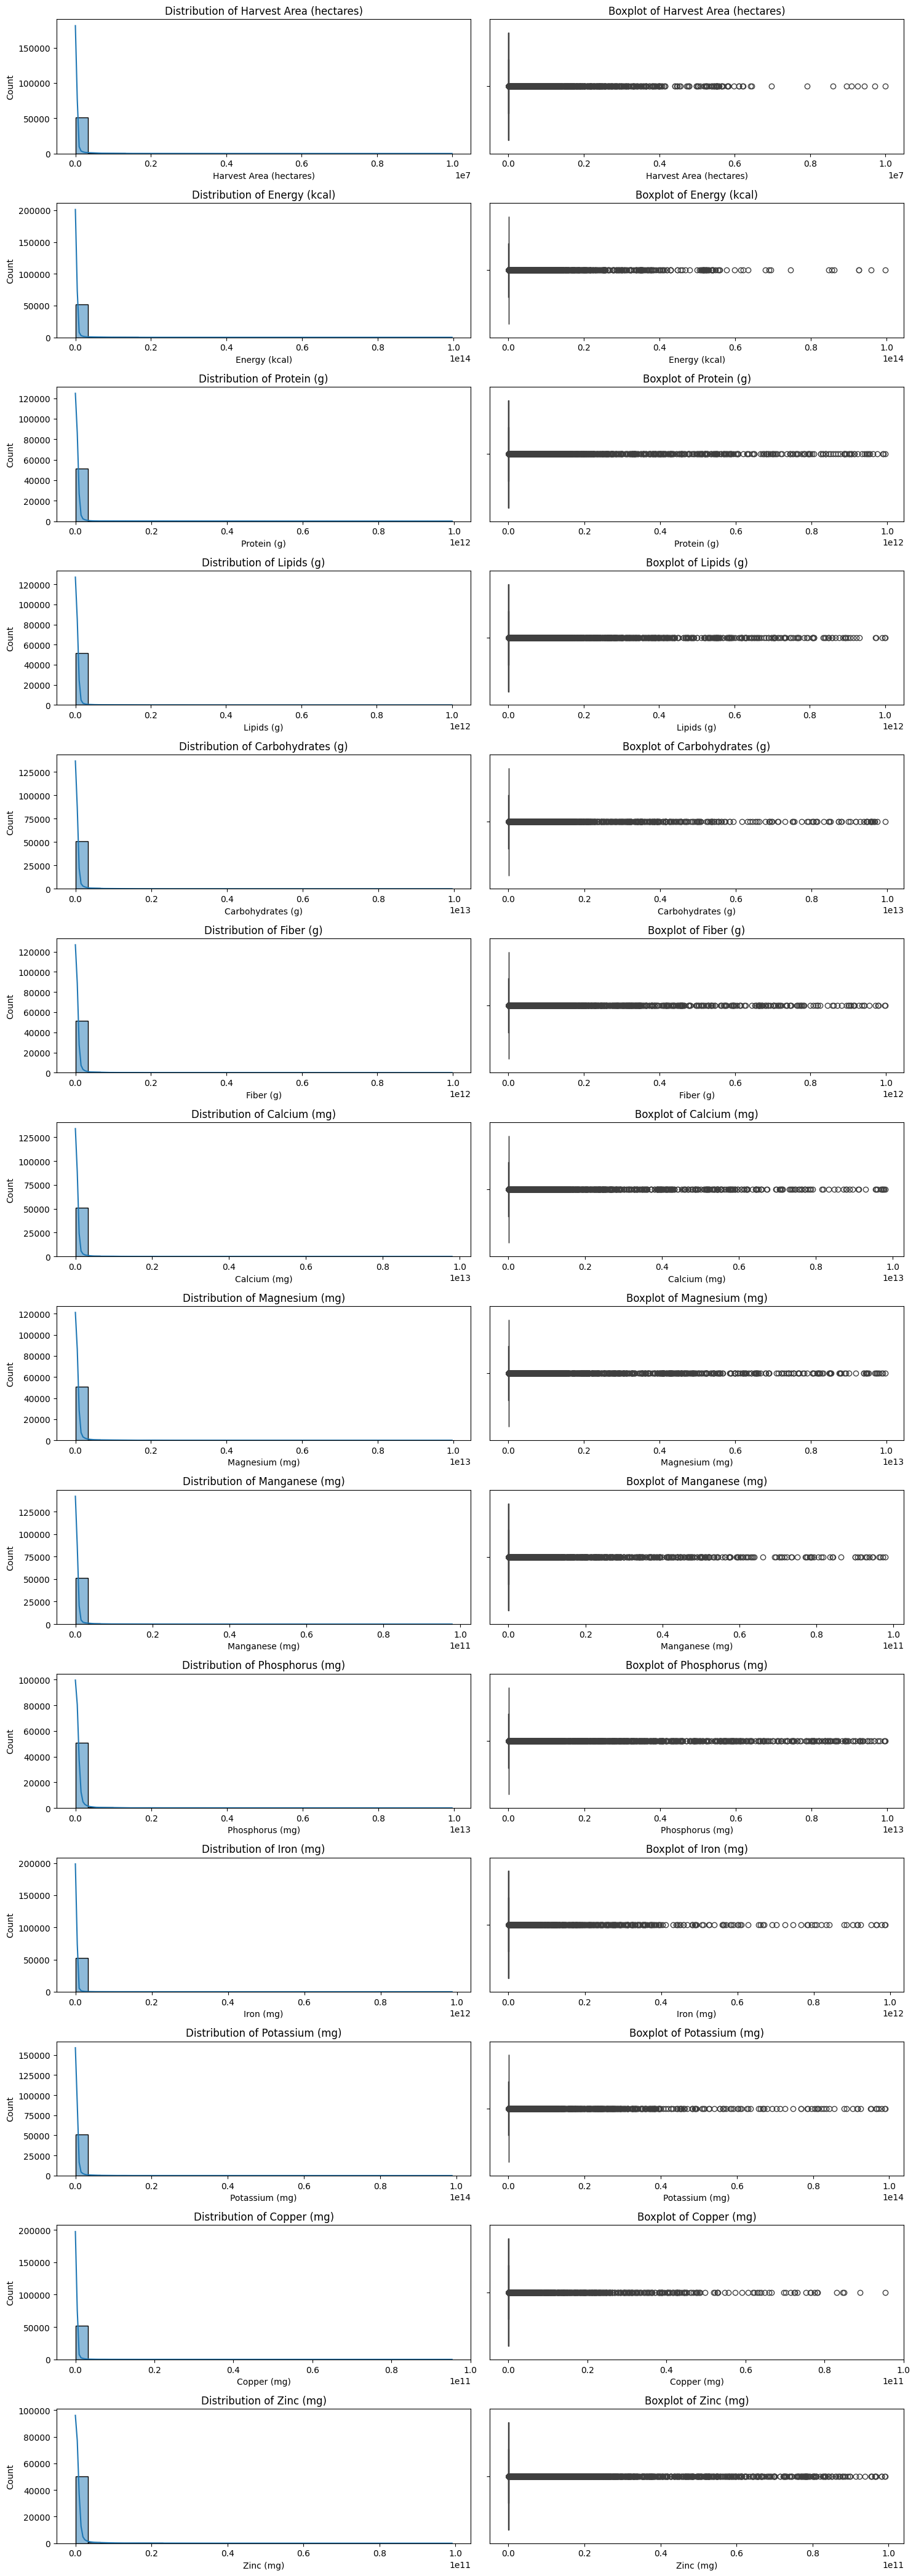

In [ ]:
#Distribution Plots for Numerical Variables
print("\n2. Distribution Plots for Numerical Variables:")
plt.figure(figsize=(15, len(numerical_cols) * 3))
for i, col in enumerate(numerical_cols, 1):
    # Histogram
    plt.subplot(len(numerical_cols), 2, 2*i-1)
    sns.histplot(df_converted[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

    # Boxplot
    plt.subplot(len(numerical_cols), 2, 2*i)
    sns.boxplot(x=df_converted[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()


3. Categorical Variable Analysis:


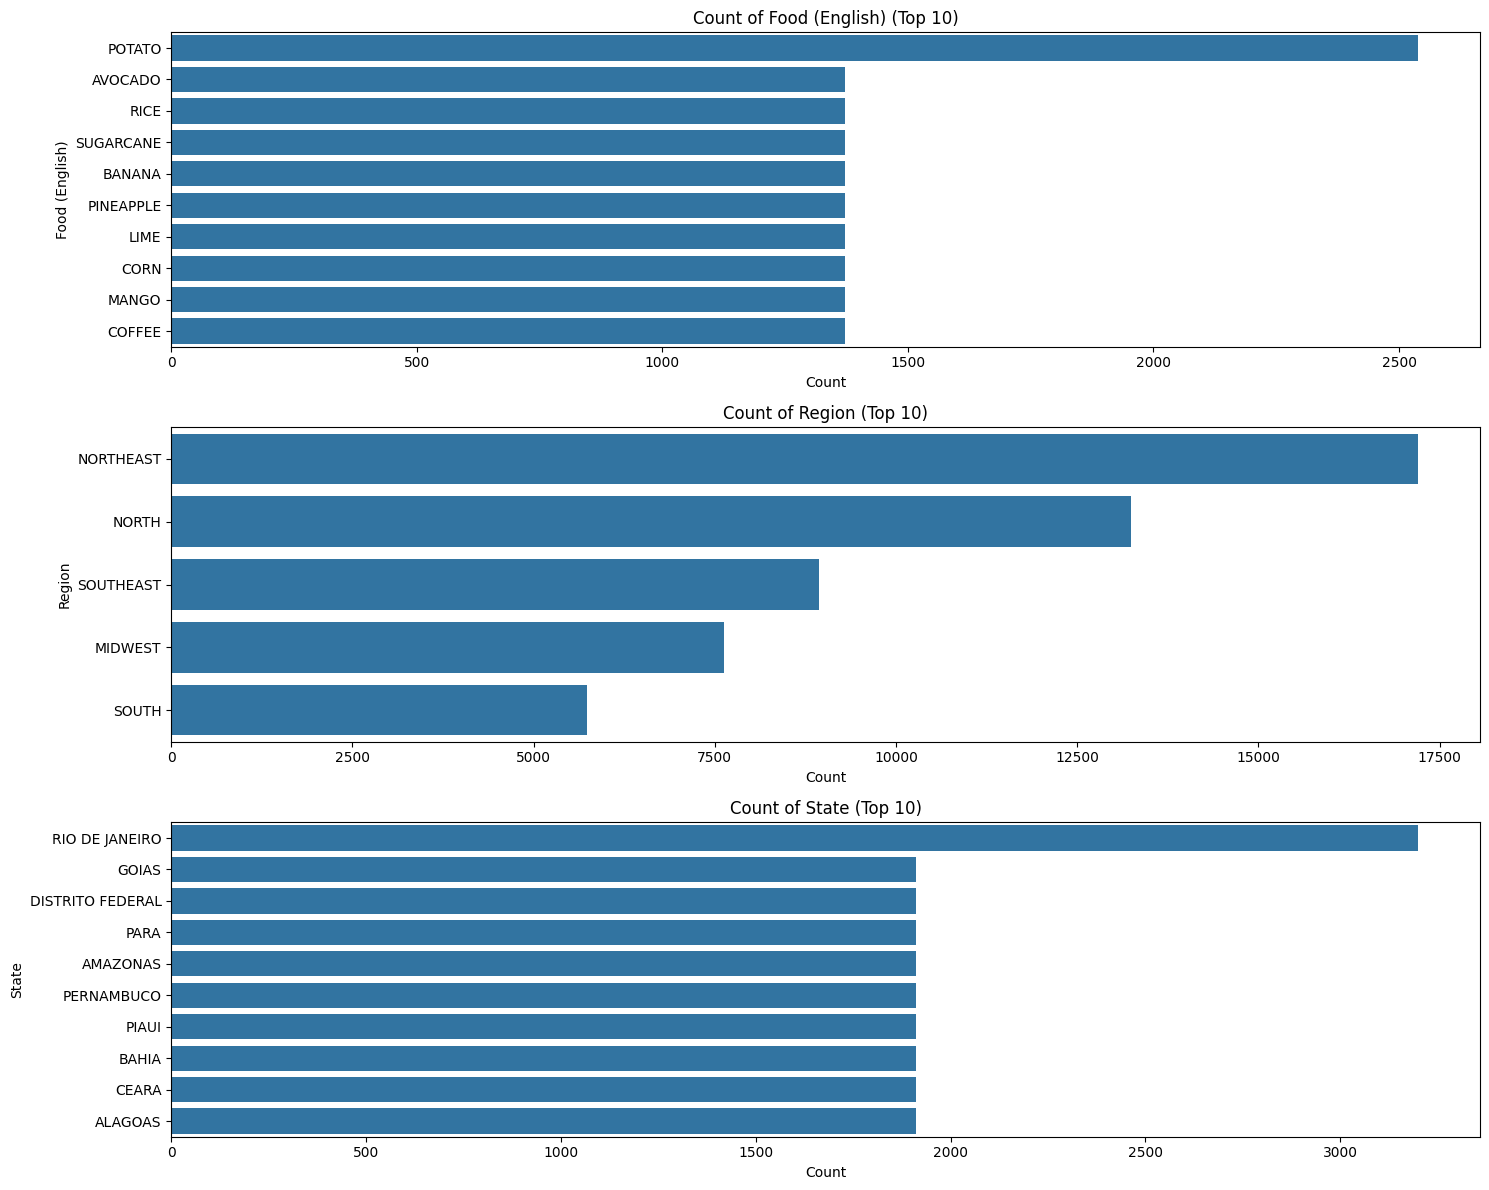

In [ ]:
#Categorical Variable Analysis
print("\n3. Categorical Variable Analysis:")
plt.figure(figsize=(15, len(categorical_cols) * 4))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(len(categorical_cols), 1, i)
    sns.countplot(y=df_converted[col], order=df_converted[col].value_counts().index[:10])  # Top 10 categories
    plt.title(f'Count of {col} (Top 10)')
    plt.xlabel('Count')
    plt.ylabel(col)
plt.tight_layout()
plt.show()


4. Correlation Analysis:


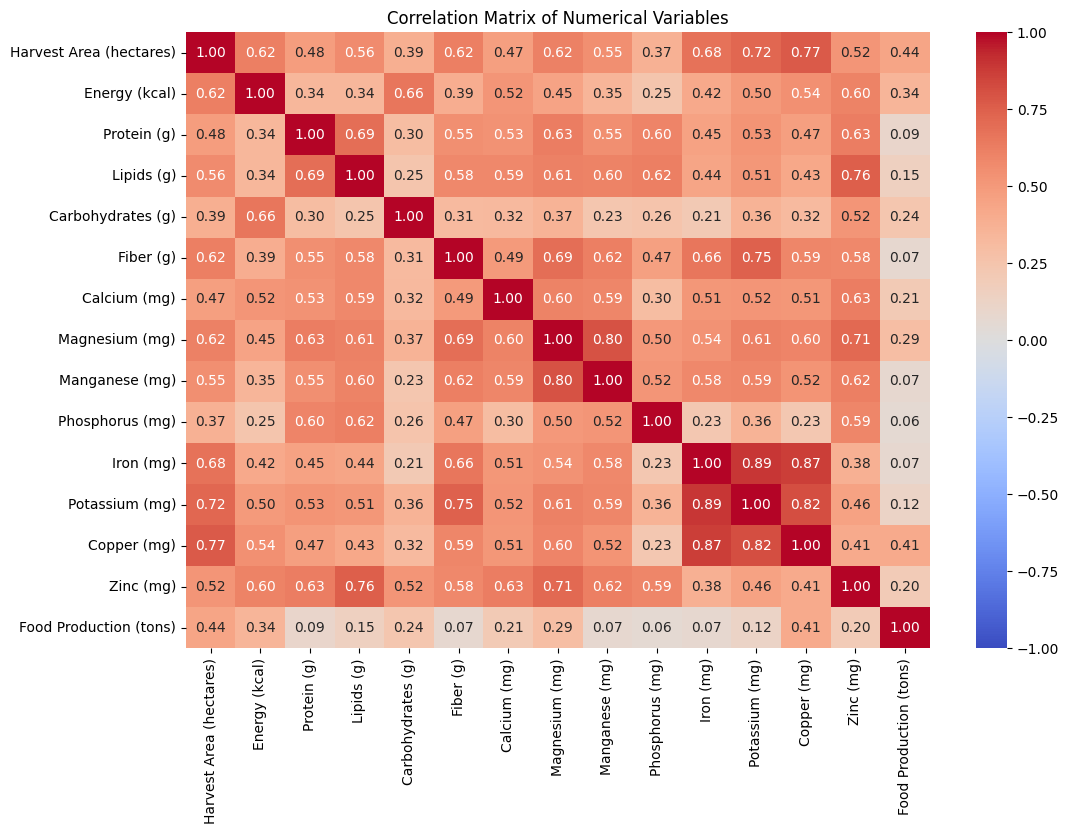

In [ ]:
#Correlation Analysis
print("\n4. Correlation Analysis:")
plt.figure(figsize=(12, 8))
correlation_matrix = df_converted[numerical_cols + ['Food Production (tons)']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()


5. Target Variable Analysis:


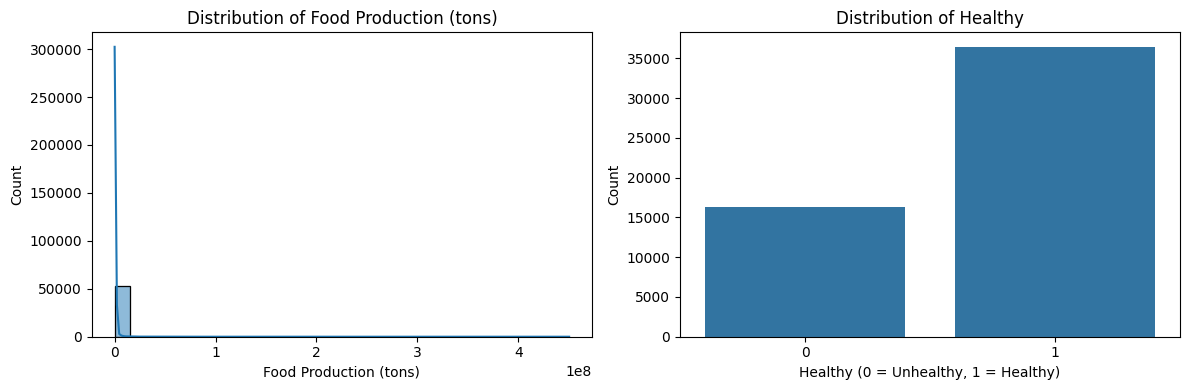

In [ ]:
#Target Variable Analysis
print("\n5. Target Variable Analysis:")

#Food Production (tons)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df_converted['Food Production (tons)'], bins=30, kde=True)
plt.title('Distribution of Food Production (tons)')
plt.xlabel('Food Production (tons)')
plt.ylabel('Count')

#Healthy
plt.subplot(1, 2, 2)
sns.countplot(x=df_converted['Healthy'])
plt.title('Distribution of Healthy')
plt.xlabel('Healthy (0 = Unhealthy, 1 = Healthy)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


6. Relationships Between Features and Targets:


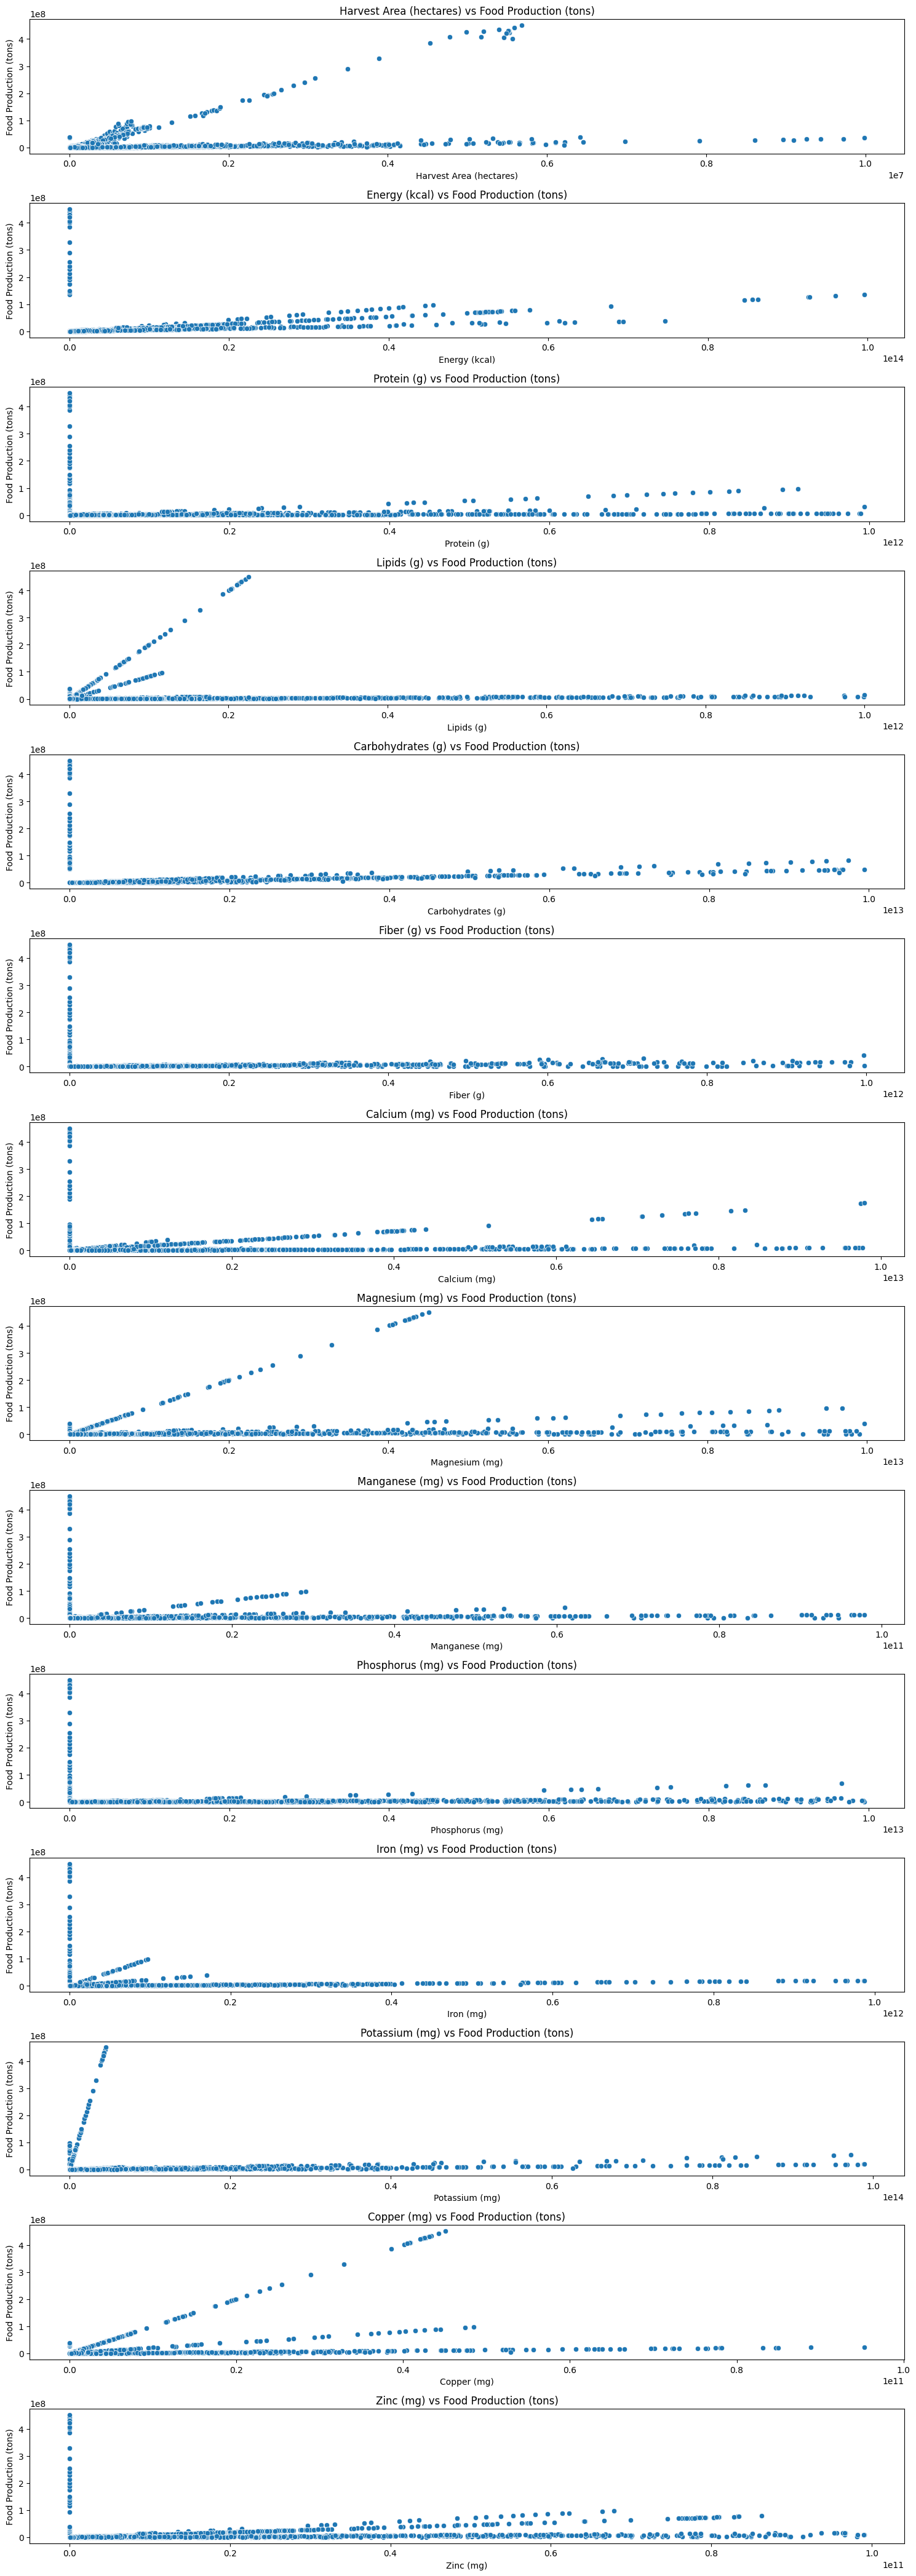

In [ ]:
#Relationships Between Features and Targets
print("\n6. Relationships Between Features and Targets:")

#Numerical features vs Food Production
plt.figure(figsize=(15, len(numerical_cols) * 3))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(len(numerical_cols), 1, i)
    sns.scatterplot(x=df_converted[col], y=df_converted['Food Production (tons)'])
    plt.title(f'{col} vs Food Production (tons)')
    plt.xlabel(col)
    plt.ylabel('Food Production (tons)')
plt.tight_layout()
plt.show()

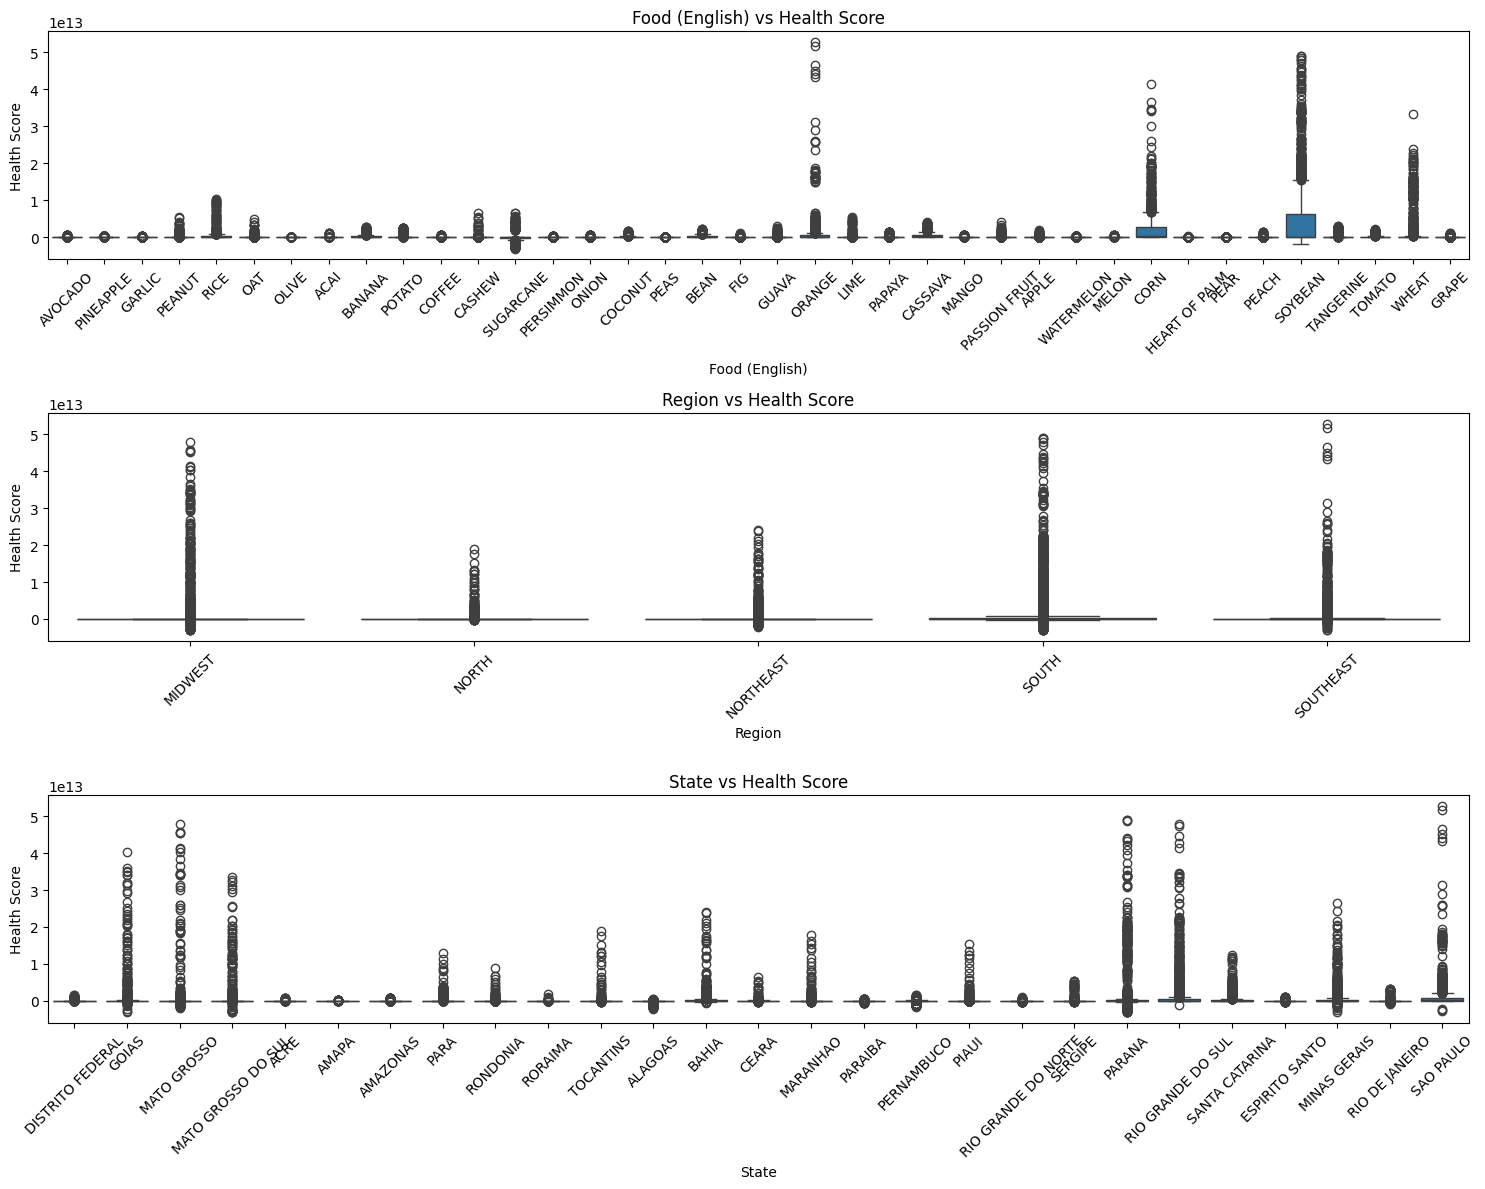

In [ ]:
#Categorical features vs Healthy
plt.figure(figsize=(15, len(categorical_cols) * 4))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(len(categorical_cols), 1, i)
    sns.boxplot(x=df_converted[col], y=df_converted['Health_Score'])
    plt.title(f'{col} vs Health Score')
    plt.xlabel(col)
    plt.ylabel('Health Score')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()